# Feature Engineering

## Business Objective

Feature engineering transforms the raw weather and sales data into meaningful variables that improve forecasting performance.

For time-series forecasting, historical sales patterns and calendar-related features often provide valuable information for predicting future demand.

---

## Objectives

- Extract calendar-based features from the date.
- Create lag features from historical sales.
- Generate rolling statistics.
- Prepare the dataset for preprocessing and model training.

In [413]:
# ==========================================================
# Feature Engineering
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [414]:
# ==========================================================
# Load Clean Dataset
# ==========================================================

df = pd.read_csv("../data/burger_data_clean.csv")

# Convert Date column back to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales
0,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45
1,2014-01-01,Reg2,16.919725,0.768124,9.974577,9.930142,1010.770295,2721.81
2,2014-01-01,Reg3,1.028776,0.548461,13.460983,12.265043,1022.632837,2240.22
3,2014-01-01,Reg4,8.070674,0.632359,13.260757,6.628645,1021.706718,468.78
4,2014-01-01,Reg5,15.207547,0.492346,9.643971,7.087097,1023.544923,137.76


## Why Feature Engineering?

Weather variables alone may not fully explain burger sales.

Customer purchasing behavior is also influenced by:

- Day of the week
- Month
- Season
- Historical sales
- Recent trends

These engineered features provide additional context for forecasting models.

In [415]:
# ==========================================================
# Calendar Features
# ==========================================================

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["DayOfWeek"] = df["Date"].dt.dayofweek

df["Quarter"] = df["Date"].dt.quarter

df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df.head()

,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear,IsWeekend
0,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45,2014,1,1,2,1,1,0
1,2014-01-01,Reg2,16.919725,0.768124,9.974577,9.930142,1010.770295,2721.81,2014,1,1,2,1,1,0
2,2014-01-01,Reg3,1.028776,0.548461,13.460983,12.265043,1022.632837,2240.22,2014,1,1,2,1,1,0
3,2014-01-01,Reg4,8.070674,0.632359,13.260757,6.628645,1021.706718,468.78,2014,1,1,2,1,1,0
4,2014-01-01,Reg5,15.207547,0.492346,9.643971,7.087097,1023.544923,137.76,2014,1,1,2,1,1,0


In [416]:
# ==========================================================
# Lag Features
# Today's sales are often related to yesterday's sales.
# ==========================================================

df["Sales_Lag_1"] = df["Sales"].shift(1)

df["Sales_Lag_7"] = df["Sales"].shift(7)

df["Sales_Lag_30"] = df["Sales"].shift(30)

df[
    [
        "Date",
        "Sales",
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Lag_30"
    ]
].head(35)

,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30
0,2014-01-01,1539.45,NaN,NaN,NaN
1,2014-01-01,2721.81,1539.45,NaN,NaN
2,2014-01-01,2240.22,2721.81,NaN,NaN
3,2014-01-01,468.78,2240.22,NaN,NaN
4,2014-01-01,137.76,468.78,NaN,NaN
5,2014-01-01,1634.90,137.76,NaN,NaN
6,2014-01-01,2245.17,1634.90,NaN,NaN
7,2014-01-01,520.35,2245.17,1539.45,NaN
8,2014-01-01,879.40,520.35,2721.81,NaN
9,2014-01-01,2451.37,879.40,2240.22,NaN


In [417]:
# ==========================================================
# Rolling Features
# ==========================================================

df["Rolling_Mean_7"] = (
    df["Sales"]
      .shift(1)
      .rolling(window=7)
      .mean()
)

df["Rolling_Mean_30"] = (
    df["Sales"]
      .shift(1)
      .rolling(window=30)
      .mean()
)

df["Rolling_STD_7"] = (
    df["Sales"]
      .shift(1)
      .rolling(window=7)
      .std()
)

In [418]:
# ==========================================================
# Missing Values After Feature Engineering
# ==========================================================

df.isnull().sum()

Date                0
Region              0
Temperature         0
Humidity            0
Wind                0
Visibility          0
Pressure            0
Sales               0
Year                0
Month               0
Day                 0
DayOfWeek           0
Quarter             0
WeekOfYear          0
IsWeekend           0
Sales_Lag_1         1
Sales_Lag_7         7
Sales_Lag_30       30
Rolling_Mean_7      7
Rolling_Mean_30    30
Rolling_STD_7       7
dtype: int64

In [419]:
# ==========================================================
# Remove Initial Missing Rows since they cannot be used for modeling
# ==========================================================

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before: {rows_before}")

print(f"Rows after : {rows_after}")

print(f"Rows removed: {rows_before - rows_after}")

Rows before: 24452
Rows after : 24422
Rows removed: 30


In [420]:
# ==========================================================
# Save Engineered Dataset
# ==========================================================

df.to_csv(
    "../data/burger_data_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


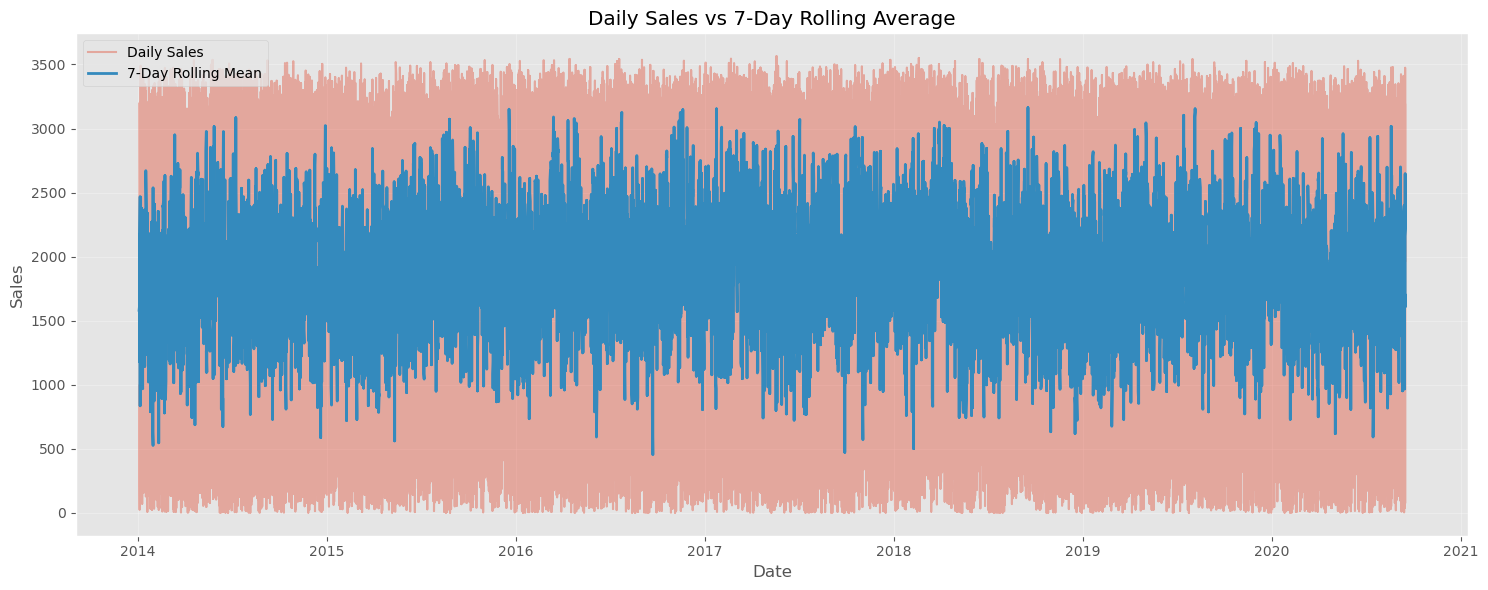

In [421]:
# ==========================================================
# Rolling Mean Visualization
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Sales"],
    alpha=0.4,
    label="Daily Sales"
)

plt.plot(
    df["Date"],
    df["Rolling_Mean_7"],
    linewidth=2,
    label="7-Day Rolling Mean"
)

plt.title("Daily Sales vs 7-Day Rolling Average")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/rolling_mean_7.png",
    dpi=300
)

plt.show()